# EDA — Validaciones TransMilenio (`dataset.csv`)

**Dataset base:** `deliveries/week06/data/transmilenio/dataset.csv`
**Periodo:** 2026/07/01 - 2026/08/31 (62 días) · **Filas:** 177,944 × 17 columnas
**Creado por:** `process_transmilenio.py` (diarios Tullave) + geolocalización (GeoJSON) + oferta (GTFS semanal).

**Variables:**
| Bloque | Columnas |
|---|---|
| Demanda | `Validaciones` (obj.) |
| Estación | `Estacion`, `num_est`, `Latitud`, `Longitud`, `Ubicacion` |
| Infraestructura | `Troncal`, `Fase`, `Cap_ART`, `Cap_BIART` |
| Oferta GTFS | `Frecuencia`, `Headway_Min`, `N_Rutas` |
| Temporal | `Fecha`, `Hora`, `Linea`, `Tipo_Dia` |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

try:
    import folium
except ImportError:
    folium = None

def _buscar(rutas):
    for r in rutas:
        p = Path(r)
        if p.exists():
            return p
    return Path(rutas[0])

RUTA_DATASET = _buscar([
    "deliveries/week06/data/transmilenio/dataset.csv",
    "../../data/transmilenio/dataset.csv",
    "../data/transmilenio/dataset.csv",
])
RUTA_TRAZADOS = _buscar([
    "deliveries/week06/data/transmilenio/geo/trazados_troncales.geojson",
    "../../data/transmilenio/geo/trazados_troncales.geojson",
    "../data/transmilenio/geo/trazados_troncales.geojson",
    "data/transmilenio/geo/trazados_troncales.geojson",
])

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 4.5)

print("Archivo:", RUTA_DATASET.resolve())
print("pandas:", pd.__version__, "| numpy:", np.__version__)

Archivo: /home/evssz/UTEC/6to/DPD/DPD_project/deliveries/week06/data/transmilenio/dataset.csv
pandas: 3.0.5 | numpy: 2.5.3


In [2]:
df = pd.read_csv(RUTA_DATASET)
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (177944, 17)


,Estacion,Latitud,Longitud,Ubicacion,Troncal,Fase,Cap_ART,Cap_BIART,num_est,Frecuencia,Headway_Min,N_Rutas,Fecha,Hora,Linea,Tipo_Dia,Validaciones
0,(02000) Portal Norte - Unicervantes,4.75,-74.05,CL 173,Autopista Norte,FASE I,132.00,78.00,2000,93.00,0.65,16.00,2026-07-01,4,(33) Zona B AutoNorte,Dia 1,507
1,(02000) Portal Norte - Unicervantes,4.75,-74.05,CL 173,Autopista Norte,FASE I,132.00,78.00,2000,314.00,0.19,28.00,2026-07-01,5,(33) Zona B AutoNorte,Dia 1,3976
2,(02000) Portal Norte - Unicervantes,4.75,-74.05,CL 173,Autopista Norte,FASE I,132.00,78.00,2000,391.00,0.15,31.00,2026-07-01,6,(33) Zona B AutoNorte,Dia 1,8280
3,(02000) Portal Norte - Unicervantes,4.75,-74.05,CL 173,Autopista Norte,FASE I,132.00,78.00,2000,439.00,0.14,31.00,2026-07-01,7,(33) Zona B AutoNorte,Dia 1,8980
4,(02000) Portal Norte - Unicervantes,4.75,-74.05,CL 173,Autopista Norte,FASE I,132.00,78.00,2000,446.00,0.13,30.00,2026-07-01,8,(33) Zona B AutoNorte,Dia 1,5727


In [3]:
info = pd.DataFrame({
    "Tipo": df.dtypes.astype(str),
    "Nulos": df.isna().sum(),
    "Únicos": df.nunique(),
})
info.style.background_gradient(subset=["Nulos"], cmap="YlOrRd")

,Tipo,Nulos,Únicos
Estacion,str,0,156
Latitud,float64,0,152
Longitud,float64,0,152
Ubicacion,str,13256,131
Troncal,str,13256,12
Fase,str,13256,3
Cap_ART,float64,13256,29
Cap_BIART,float64,13256,20
num_est,int64,0,153
Frecuencia,float64,8735,463


## 2. Inspección inicial

- **Unidad de análisis:** una fila = total de *validaciones* de una **`Linea`** en una **estación** durante una **hora** de un **día** (`Tipo_Dia`).
- `Estacion` incluye el código Tullave de 5 dígitos; `num_est` lo repite como entero (clave de unión con zonas industriales del GTFS).
- `Validaciones` = pasajeros que ingresan por los torniquetes de la estación en esa celda.
- `Cap_ART` / `Cap_BIART` están **sin definir** (NA) para las estaciones que no tienen capacidad oficial reportada (corrales/centros de control, ver sección de nulos).

In [4]:
df.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Latitud,"177,944.00",4.64,0.05,4.53,4.55,4.57,4.60,4.63,4.68,4.74,4.76,4.77
Longitud,"177,944.00",-74.10,0.03,-74.21,-74.20,-74.17,-74.12,-74.09,-74.07,-74.05,-74.04,-74.04
Cap_ART,"164,688.00",148.63,47.91,0.00,36.00,80.00,128.00,144.00,168.00,224.00,320.00,336.00
Cap_BIART,"164,688.00",103.36,44.03,0.00,0.00,48.00,72.00,120.00,120.00,168.00,216.00,288.00
num_est,"177,944.00","7,456.45","7,103.35","2,000.00","2,001.00","2,200.00","4,100.00","7,005.00","9,104.00","12,007.00","50,008.00","57,503.00"
Frecuencia,"169,209.00",99.66,73.64,0.00,0.00,13.00,51.00,84.00,127.00,242.00,382.00,492.00
Headway_Min,"163,619.00",1.05,1.94,0.12,0.16,0.24,0.47,0.69,1.09,2.86,6.67,60.00
N_Rutas,"169,209.00",9.25,5.82,0.00,0.00,2.00,6.00,8.00,12.00,22.00,29.00,38.00
Hora,"177,944.00",13.08,5.66,0.00,3.00,4.00,8.00,13.00,18.00,22.00,23.00,23.00
Validaciones,"177,944.00",499.51,938.36,1.00,1.00,5.00,74.00,225.00,513.00,"1,903.00","4,769.57","15,308.00"


## 3. Limpieza

### 3.1 Tipos de dato

`Fecha` se lee como texto y `Frecuencia`/`Headway_Min`/`N_Rutas`/capacidades vienen como flotante con `NaN`. Normalizamos:
- `Fecha` -> `datetime` (sin zona horaria, hora 00:00).
- `Hora` y `num_est` -> enteros.
- Oferta y capacidades -> numérico (los `NaN` son tratados posteriormente).

In [5]:
df["Fecha"] = pd.to_datetime(df["Fecha"])
df["Hora"] = df["Hora"].astype(int)
df["num_est"] = df["num_est"].astype(int)
for c in ["Frecuencia", "Headway_Min", "N_Rutas", "Cap_ART", "Cap_BIART"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df["Validaciones"] = df["Validaciones"].astype(int)
df.dtypes.astype(str)

Estacion                   str
Latitud                float64
Longitud               float64
Ubicacion                  str
Troncal                    str
Fase                       str
Cap_ART                float64
Cap_BIART              float64
num_est                  int64
Frecuencia             float64
Headway_Min            float64
N_Rutas                float64
Fecha           datetime64[us]
Hora                     int64
Linea                      str
Tipo_Dia                   str
Validaciones             int64
dtype: str

### 3.2 Cobertura temporal y duplicados

El rango oficial de extracción es **2026/07/01 - 2026/08/31 (62 días)**. Comprobamos que el archivo contenga exactamente esa ventana, sin huecos ni días de fuera

In [6]:
dias = set(df["Fecha"].dt.date.unique())
esperados = set(pd.date_range("2026-07-01", "2026-08-31").date)
print("días en el archivo:", len(dias))
print("faltan :", sorted(esperados - dias))
print("sobran :", sorted(dias - esperados))
print()
print("duplicados exactos (17 columnas):", df.duplicated().sum())
print("duplicados por (num_est, Fecha, Hora, Linea):",
      df.duplicated(["num_est", "Fecha", "Hora", "Linea"]).sum())

días en el archivo: 63
faltan : []
sobran : [datetime.date(2026, 9, 1)]

duplicados exactos (17 columnas): 0
duplicados por (num_est, Fecha, Hora, Linea): 1179


Existe **1 día extra** (2026/09/01). Como estamos tomando una ventada de 62 días lo descartamos, ya que el dataset de clima contiene 62 días. Guardamos un respaldo `df_raw` por si hace falta auditar.

In [7]:
df_raw = df.copy()
sobra = set(df["Fecha"].dt.date.unique()) - set(pd.date_range("2026-07-01", "2026-08-31").date)
if sobra:
    print("Descartando fechas fuera de rango:", sorted(sobra))
    df = df[~df["Fecha"].dt.date.isin(sobra)]
print("Filas tras acotar:", len(df))

Descartando fechas fuera de rango: [datetime.date(2026, 9, 1)]
Filas tras acotar: 177936


#### Hallazgos

Revisando los duplicados por clave de celda encontramos dos fenómenos **distintos**:

1. **Celdas partidas:** la fila repite la misma celda completa `(num_est, Fecha, Hora, Linea, Tipo_Dia)` con `Validaciones` **divididas** (p. ej. estación 9110 el 2026/07/01 h. 05 `(36) Zona A Caracas`: `76` y `11` en dos filas). Es un **artefacto del agregado** de `process_transmilenio.py`: la hora se agrega por minuto y se trunca a hora en la salida -> dos claves interna colisionan al escribir el CSV.
2. **Doble Tipo_Dia:** el mismo `(num_est, Fecha, Hora, Linea)` con los **dos** `Tipo_Dia` (p. ej. un domingo que reporta casi toda su demanda en `Dia 2` pero conserva un `Dia 1`
   residual del feed Tullave).

En ambos casos la **suma total de validaciones no cambia** al regenerar una sola celda (528,893 validaciones intactas). El solo efecto es que el modelo leería **dos observaciones** de la misma celda.

**Decisión de limpieza:** colapsar cada celda **sumando** `Validaciones`. La oferta GTFS y los atributos de estación son idénticos dentro de cada celda, así que conservamos `last` del resto.

In [8]:
key = ["num_est", "Fecha", "Hora", "Linea", "Tipo_Dia"]
key_linea = ["num_est", "Fecha", "Hora", "Linea"]

# descomposición de los duplicados por celda
n_partidas = int(df.duplicated(key, keep=False).sum() // 2)
n_grupos_linea = int(df[df.duplicated(key_linea, keep=False)].groupby(key_linea).ngroups)
print(f"celdas partidas (misma clave completa + Validaciones divididas): {n_partidas}")
print(f"celdas con doble Tipo_Dia                                : {n_grupos_linea - n_partidas}")

print("filas antes:", len(df), "| celdas clave (antes):", df[key].drop_duplicates().shape[0])

antes = len(df)
rest = [c for c in df.columns if c not in key]
df = (df.groupby(key, as_index=False)
        .agg({c: ("sum" if c == "Validaciones" else "last") for c in rest})
        [key + rest])
print("filas después (colapsadas):", len(df), "| reducción:", antes - len(df))
print("total Validaciones tras colapsar:", f"{int(df['Validaciones'].sum()):,}",
      "| del original:", f"{int(df_raw['Validaciones'].sum()):,}")

celdas partidas (misma clave completa + Validaciones divididas): 1153
celdas con doble Tipo_Dia                                : 26
filas antes: 177936 | celdas clave (antes): 176783
filas después (colapsadas): 176783 | reducción: 1153
total Validaciones tras colapsar: 88,884,983 | del original: 88,884,991


### 3.3 Verificación de la clasificación de días

La demanda de un festivo cae al nivel de un domingo, pero si `Tipo_Dia` lo rotula como `Dia 1` (hábil), cualquier cruce contra el clima puede confundir ese "día de baja demanda" con un efecto de lluvia. Antes de seguir, **verificamos que la etiqueta haga bien su trabajo**: comparamos cada día de la ventana con el calendario oficial colombiano 2026 — domingos -> `Dia 2`; festivos `13/07`, `20/07`, `07/08` y `17/08` -> `Dia 2` (Electro Emiliani: `13/07` y `17/08` son traslados al lunes; `20/07` y `07/08` son fechas patrias fijas).

In [9]:
FESTIVOS = pd.to_datetime(["2026-07-13", "2026-07-20", "2026-08-07", "2026-08-17"])

df["_wd"] = df["Fecha"].dt.dayofweek                      # 0=Lun ... 6=Dom

cal = (df.groupby("Fecha")
         .agg(Tipo_Dia=("Tipo_Dia", lambda s: s.mode().iloc[0]),
              wd=("_wd", "first"),
              Validaciones=("Validaciones", "sum"))
         .reset_index())
cal["Es_Domingo"] = cal["wd"] == 6
cal["Es_Festivo"] = cal["Fecha"].isin(FESTIVOS)
cal["Esperado"] = np.where(cal["Es_Domingo"] | cal["Es_Festivo"], "Dia 2", "Dia 1")
cal["Coincide"] = cal["Tipo_Dia"] == cal["Esperado"]

print("Clasificación esperada (calendario) vs etiqueta real (Tipo_Dia):")
print(pd.crosstab(cal["Esperado"], cal["Tipo_Dia"]))
print()
print("Días donde la etiqueta NO coincide con el calendario:")
print(cal.loc[~cal["Coincide"],
              ["Fecha", "wd", "Tipo_Dia", "Esperado", "Es_Festivo", "Validaciones"]]
     .to_string(index=False))

# Corrección para el downstream (EDA de clima): mantiene Tipo_Dia original.
df["Es_Festivo"] = df["Fecha"].isin(FESTIVOS)
df["Tipo_Dia_ok"] = np.where(
    (df["Fecha"].dt.dayofweek == 6) | df["Es_Festivo"], "Dia 2", "Dia 1")

print()
print("Con la clasificación corregida (Tipo_Dia_ok):")
print(df["Tipo_Dia_ok"].value_counts().to_string())

df.drop(columns=["_wd"], inplace=True)
print("filas con Tipo_Dia_ok, sin _wd:", len(df), "| columnas:", len(df.columns))

Clasificación esperada (calendario) vs etiqueta real (Tipo_Dia):
Tipo_Dia  Dia 1  Dia 2
Esperado              
Dia 1        49      0
Dia 2         4      9

Días donde la etiqueta NO coincide con el calendario:
     Fecha  wd Tipo_Dia Esperado  Es_Festivo  Validaciones
2026-07-13   0    Dia 1    Dia 2        True        494875
2026-07-20   0    Dia 1    Dia 2        True        472539
2026-08-07   4    Dia 1    Dia 2        True        525834
2026-08-17   0    Dia 1    Dia 2        True        486695

Con la clasificación corregida (Tipo_Dia_ok):
Tipo_Dia_ok
Dia 1    140941
Dia 2     35842
filas con Tipo_Dia_ok, sin _wd: 176783 | columnas: 19


**Hallazgo:** el campo `Tipo_Dia` del dato fuente marca los **domingos** como `Dia 2`, pero los **4 festivos** de
la ventana (`13/07`, `20/07`, `07/08`, `17/08`) llegan como `Dia 1` (hábil). No se debe usar `Tipo_Dia` para separar festivos.
Ahora se incluyen 2 features:
- `Es_Festivo`: booleano según el calendario oficial colombiano de la ventana.
- `Tipo_Dia_ok`: clasificación corregida (`Dia 2` = domingo **o** festivo), conservando `Tipo_Dia`
  original para trazabilidad.

### 3.4 Tratamiento de nulos

Revisamos cada columna y decidimos una política explícita.

In [10]:
na = df[["Frecuencia", "Headway_Min", "N_Rutas", "Cap_ART", "Cap_BIART"]].isna().sum()
(na / len(df)).to_frame("pct_nulos").assign(nulos=na).style.format("{:.1%}", subset=["pct_nulos"])

,pct_nulos,nulos
Frecuencia,4.9%,8727
Headway_Min,8.1%,14279
N_Rutas,4.9%,8727
Cap_ART,7.5%,13256
Cap_BIART,7.5%,13256


¿Qué estaciones/troncales tienen Frecuencia NA?

In [11]:
sin_of = df[df["Frecuencia"].isna()]
print("Filas sin oferta:", len(sin_of), f"({100*len(sin_of)/len(df):.1f}%)")
print("Estaciones afectadas:", sin_of["num_est"].nunique())
print()
print(sin_of["Troncal"].value_counts().to_string())
print()
# ejemplo característico: 57503 Ampliación San Mateo (corral de buses, no es estación BRT)
sin_of.groupby(["num_est", "Estacion"], as_index=False).size().sort_values("size", ascending=False).head(10)

Filas sin oferta: 8727 (4.9%)
Estaciones afectadas: 88

Troncal
Caracas Sur        2810
Americas           1351
Suba               1278
Calle 80           1226
NQS Sur             404
Caracas              91
Carrera 10           85
Autopista Norte      65
Calle 26             10
NQS Central           6
Carrera 7             3



,num_est,Estacion,size
55,9000,(09000) Cabecera Usme,1296
60,9005,(09005) Danubio,1252
87,57503,(57503) Ampliacion San Mateo,1239
14,3011,(03011) SUBA - CALLE 100,1216
17,4100,(04100) Carrera 77,1200
80,12003,(12003) Ricaurte,1178
66,9122,(09122) Calle 72 - Areandina,90
24,5002,(05002) Tintal,62
48,7503,(07503) SAN MATEO - C.C. UNISUR,62
49,7504,(07504) TERREROS,61


**Interpretación de `Frecuencia` NA:** son celdas cuya estación **no existe como parada en el GTFS** (corrales/patios como Ampliación San Mateo, o cables aéreos y andenes sueltos). No hay oferta programada, no hay frecuencia, no hay headway ni rutas.

**Política:**
- `Frecuencia` NA -> **0** (no hay servicio); con un nuevo feature `Sin_Oferta` para no confundirlo con un servicio de frecuencia 0 real.
- `Headway_Min`/`N_Rutas` quedan como `NaN`.
- `Cap_ART`/`Cap_BIART` con NA, es si son sin capacidad oficial. Las **dejamos en NaN** y trabajamos con `Cap_total` y el nuevo feature `sin_capacidad` en el análisis de saturación (no imputamos porque el modelo podrá decidir).

In [12]:
# Oferta: NA -> "no hay servicio programado" (0), con flag de trazabilidad
df["Sin_Oferta"] = df["Frecuencia"].isna()
df["Frecuencia"] = df["Frecuencia"].fillna(0)

# Capacidad total (articulado + biarticulado) y flag
df["Cap_total"] = df["Cap_ART"].fillna(0) + df["Cap_BIART"].fillna(0)
df["sin_capacidad"] = df["Cap_total"] == 0

print("Sin oferta:", df["Sin_Oferta"].sum(), "| con oferta:", (~df["Sin_Oferta"]).sum())
print("sin_capacidad:", df["sin_capacidad"].sum())

Sin oferta: 8727 | con oferta: 168056
sin_capacidad: 14670


### 3.5 Rangos y consistencia

Verificamos invariantes:
- `Validaciones >= 1` (celdas no vacías) y máximos plausibles
- Capacidades no negativas.
- Si `Frecuencia > 0` -> debe existir `Headway_Min` = `60 / Frecuencia`.
- Si `Frecuencia == 0` -> `Headway_Min` debe ser `NaN`.

In [13]:
print("Validaciones  min/max:", df["Validaciones"].min(), df["Validaciones"].max(),
      "| negativas:", (df["Validaciones"] < 0).sum())
print("Cap_ART/BIART negativas:", int((df["Cap_ART"] < 0).sum()), int((df["Cap_BIART"] < 0).sum()))

frec_pos = df["Frecuencia"] > 0
print("Frecuencia>0 sin Headway:", int((frec_pos & df["Headway_Min"].isna()).sum()))
print("Frecuencia=0 con Headway:", int((~frec_pos & df["Headway_Min"].notna()).sum()))

calc = (60 / df.loc[frec_pos, "Frecuencia"])
mismatch = (df.loc[frec_pos, "Headway_Min"] - calc).abs() > 1e-6
print("Headway != 60/Frecuencia:", int(mismatch.sum()))

Validaciones  min/max: 1 15308 | negativas: 0
Cap_ART/BIART negativas: 0 0
Frecuencia>0 sin Headway: 0
Frecuencia=0 con Headway: 0
Headway != 60/Frecuencia: 146012


## 4. Feature engineering

Creamos variables derivadas que se usarán en el análisis y en el modelado posterior:
- `DiaSemana` (Lunes…Domingo) y `Es_Habil` (equivalente a `Tipo_Dia_ok == "Dia 1"`).
- `Franja` horaria (madrugada / pico am / valle / pico pm / noche).
- `Pax_bus` = pasajeros por bus = `Validaciones / Frecuencia` (indicador de saturación de la oferta).
- `Ocupacion_pk` = `Validaciones / Cap_total` (proxy de ocupación de la infraestructura).
- `log_val` = `log1p(Validaciones)` para gráficos de distribuciones con cola larga.


In [14]:
DOW = {0: "Lunes", 1: "Martes", 2: "Miércoles", 3: "Jueves", 4: "Viernes", 5: "Sábado", 6: "Domingo"}
ORDEN_DIAS = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
ORDEN_FRANJA = ["madrugada", "pico am", "valle", "pico pm", "noche"]

def _franja(h):
    if h < 5:  return "madrugada"
    if h < 9:  return "pico am"
    if h < 16: return "valle"
    if h < 21: return "pico pm"
    return "noche"

df["DiaSemana"] = df["Fecha"].dt.dayofweek.map(DOW)
df["Franja"] = df["Hora"].map(_franja)
df["Es_Habil"] = df["Tipo_Dia_ok"] == "Dia 1"
df["Pax_bus"] = df["Validaciones"] / df["Frecuencia"].replace(0, np.nan)
df["Ocupacion_pk"] = df["Validaciones"] / df["Cap_total"].replace(0, np.nan)
df["log_val"] = np.log1p(df["Validaciones"])

df[["Fecha", "Hora", "DiaSemana", "Franja", "Tipo_Dia", "Tipo_Dia_ok", "Es_Festivo", "Frecuencia",
    "Pax_bus", "Ocupacion_pk", "Cap_total"]].head()


,Fecha,Hora,DiaSemana,Franja,Tipo_Dia,Tipo_Dia_ok,Es_Festivo,Frecuencia,Pax_bus,Ocupacion_pk,Cap_total
0,2026-07-01,4,Miércoles,madrugada,Dia 1,Dia 1,False,93.00,5.45,2.41,210.00
1,2026-07-01,5,Miércoles,pico am,Dia 1,Dia 1,False,314.00,12.66,18.93,210.00
2,2026-07-01,6,Miércoles,pico am,Dia 1,Dia 1,False,391.00,21.18,39.43,210.00
3,2026-07-01,7,Miércoles,pico am,Dia 1,Dia 1,False,439.00,20.46,42.76,210.00
4,2026-07-01,8,Miércoles,pico am,Dia 1,Dia 1,False,446.00,12.84,27.27,210.00


## 5. Análisis

### 5.1 Demanda global y serie temporal

In [15]:
filas_x_est_dia = len(df) / (df["num_est"].nunique() * df["Fecha"].dt.normalize().nunique())
resumen = pd.Series({
    "Filas": len(df),
    "Validaciones totales": int(df["Validaciones"].sum()),
    "Estaciones": df["num_est"].nunique(),
    "Días": df["Fecha"].dt.normalize().nunique(),
    "Troncales": df["Troncal"].nunique(),
    "Líneas": df["Linea"].nunique(),
    "Filas promedio por estación-día": round(filas_x_est_dia, 1),
}, name="Valor")
resumen.to_frame().style.format("{:,.0f}")

,Valor
Filas,"176,783"
Validaciones totales,"88,884,983"
Estaciones,153
Días,62
Troncales,12
Líneas,13
Filas promedio por estación-día,19


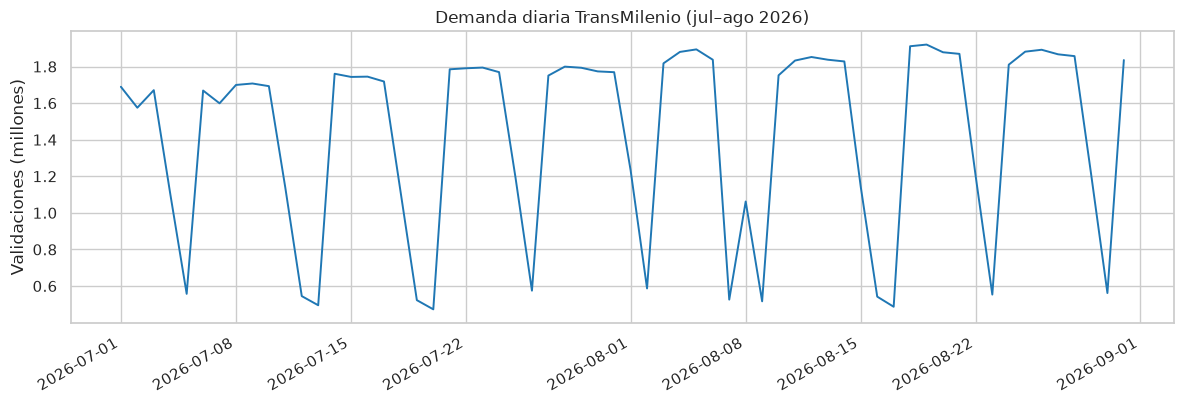

Fecha
2026-08-07   -1,311,217.00
2026-08-15     -686,603.00
2026-08-22     -676,636.00
2026-08-30     -655,666.00
Name: Validaciones, dtype: float64

In [16]:
serie_dia = df.groupby("Fecha")["Validaciones"].sum()
fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(serie_dia.index, serie_dia.values, lw=1.4, color="#1f77b4")
ax.set_title('Demanda diaria TransMilenio (jul–ago 2026)')
ax.set_ylabel('Validaciones (millones)')
ax.yaxis.set_major_formatter(lambda x, _: f"{x/1e6:.1f}")
fig.autofmt_xdate()
plt.tight_layout(); plt.show()

# caídas semanales (domingo) y posible festivo
serie_dia.diff().sort_values().head(4)

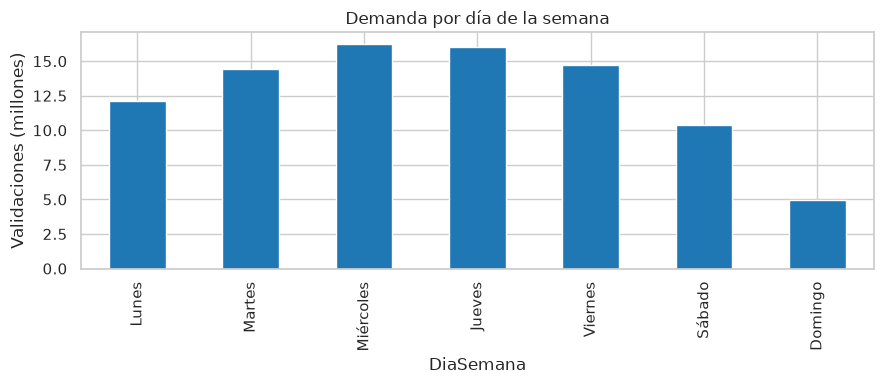

Tipo_Dia
Dia 1   0.94
Dia 2   0.06
Name: Validaciones, dtype: float64

In [17]:
dow = df.groupby("DiaSemana")["Validaciones"].sum().reindex(ORDEN_DIAS)
fig, ax = plt.subplots(figsize=(9, 4))
ax = dow.plot.bar(ax=ax, color="#2ca02c" if False else "#1f77b4")
ax.set_title('Demanda por día de la semana')
ax.set_ylabel('Validaciones (millones)')
ax.yaxis.set_major_formatter(lambda x, _: f"{x/1e6:.1f}")
plt.tight_layout(); plt.show()

# distribución por tipo de día: Dias para el modelo
df.groupby("Tipo_Dia")["Validaciones"].sum() / df["Validaciones"].sum()

**Hallazgos:** el domingo (Día 2) cae a 2/3 de la demanda hábil; el festivo del 20 de julio (lunes) también crea un valle. La demanda total del periodo ronda los **88.9 millones de validaciones**.

### 5.2 Patrón horario y franjas

La hora es la dimensión más predictiva de la demanda: buscamos el doble pico (mañana 5–8 h, tarde 16–20 h) y la forma según tipo de día.

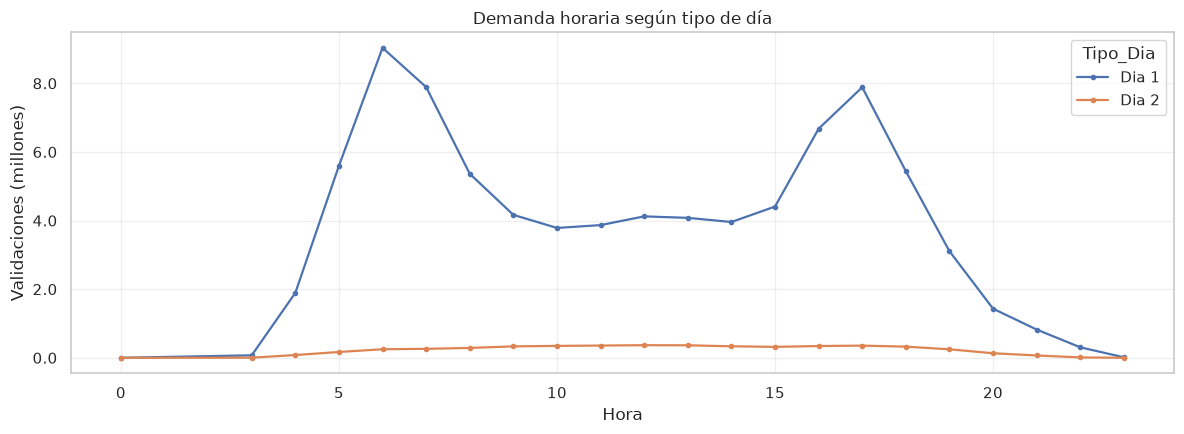

In [18]:
per_hora = df.groupby(["Tipo_Dia", "Hora"])["Validaciones"].sum().unstack(0)
fig, ax = plt.subplots(figsize=(12, 4.5))
per_hora.plot(ax=ax, lw=1.6, marker="o", ms=3)
ax.set(title="Demanda horaria según tipo de día", xlabel="Hora", ylabel="Validaciones (millones)")
ax.yaxis.set_major_formatter(lambda x, _: f"{x/1e6:.1f}")
ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

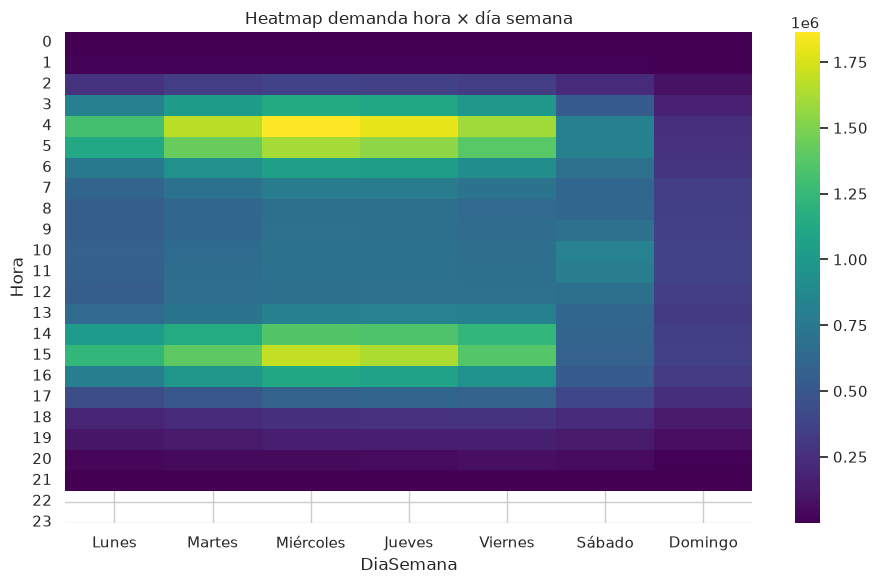

In [19]:
hm = (df.pivot_table(index="Hora", columns="DiaSemana", values="Validaciones", aggfunc="sum")
         .reindex(columns=ORDEN_DIAS))
fig, ax = plt.subplots(figsize=(9.5, 6))
sns.heatmap(hm, cmap="viridis", ax=ax, xticklabels=True, yticklabels=range(24))
ax.set_title("Heatmap demanda hora × día semana")
plt.tight_layout(); plt.show()

In [20]:
franjas = (df.groupby("Franja")["Validaciones"].sum()
               .reindex(ORDEN_FRANJA).rename("Val"))
(franjas / franjas.sum()).mul(100).round(1).to_frame("pct_demanda")

,pct_demanda
Franja,
madrugada,2.30
pico am,32.50
valle,34.70
pico pm,29.20
noche,1.40


### 5.3 Dimensión geográfica: estaciones, troncales y fases

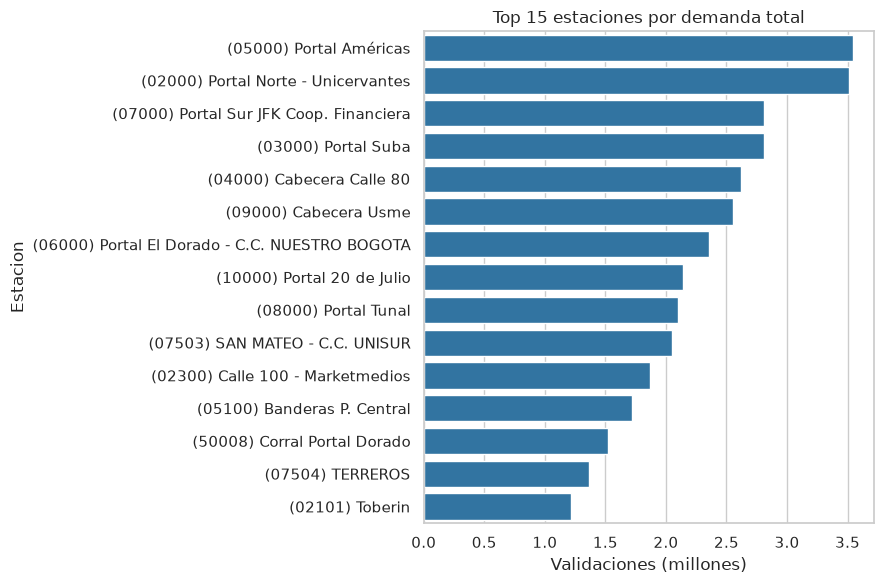

In [21]:
top = (df.groupby(["num_est", "Estacion"], as_index=False)["Validaciones"].sum()
           .sort_values("Validaciones", ascending=False).head(15))
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top, x="Validaciones", y="Estacion", ax=ax, color="#1f77b4")
ax.set_title('Top 15 estaciones por demanda total')
ax.set_xlabel('Validaciones (millones)')
ax.xaxis.set_major_formatter(lambda x, _: f"{x/1e6:.1f}")
plt.tight_layout(); plt.show()

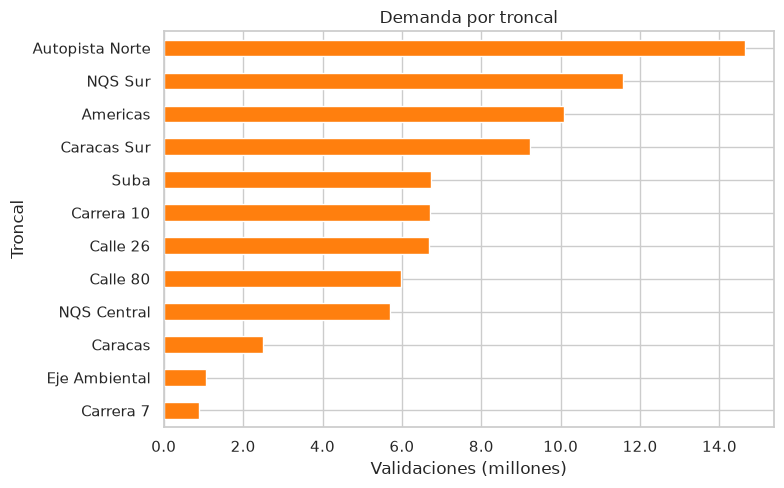

Fase: {'FASE I': 37.6, 'FASE II': 37.7, 'FASE III': 16.8}


In [22]:
tr = df.groupby("Troncal")["Validaciones"].sum().sort_values()
fig, ax = plt.subplots(figsize=(8, len(tr) * 0.42))
tr.plot.barh(ax=ax, color="#ff7f0e")
ax.set_title('Demanda por troncal')
ax.set_xlabel('Validaciones (millones)')
ax.xaxis.set_major_formatter(lambda x, _: f"{x/1e6:.1f}")
plt.tight_layout(); plt.show()

print("Fase:", (df.groupby("Fase")["Validaciones"].sum() / df["Validaciones"].sum()).mul(100).round(1).to_dict())

In [23]:
import json as _json
from branca.colormap import linear as _cm

nivel  = "dow"              # "día" | "dow" | "hora"
fecha  = "2026-07-26"       # (nivel = "día")  día específico a mostrar
dia_sem = "Martes"           # (nivel = "dow")  total por día de la semana
hora   = 8                  # (nivel = "hora")  hora 0-23 (todo el periodo)

if nivel == "día":
    d = pd.Timestamp(fecha).date()
    sub = df[df["Fecha"].dt.date == d]
    label = f"día {d}"
elif nivel == "dow":
    sub = df[df["DiaSemana"] == dia_sem]
    label = f"total de todos los {dia_sem.lower()} del periodo"
else:
    sub = df[df["Hora"] == hora]
    label = f"hora {hora:02d}:00 (todo el periodo)"

print(f"Viendo {label}: {len(sub):,.0f} filas, "
      f"{int(sub['Validaciones'].sum()):,} validaciones")
print("días disponibles:", df["Fecha"].dt.date.min(), "→", df["Fecha"].dt.date.max())

if folium is None:
    print("instala folium para ver el mapa")
    m = None
elif len(sub) == 0:
    print("Sin datos para esa selección.")
    m = None
else:
    geo = (sub.groupby("num_est", as_index=False)
              .agg(lat=("Latitud", "mean"), lon=("Longitud", "mean"),
                   val=("Validaciones", "sum"), est=("Estacion", "first")))
    vmax = float(geo["val"].max())
    cmap = _cm.YlOrRd_09.scale(0.0, float(np.log1p(vmax)))
    _fmt = lambda x: (f"{x/1e6:.1f}M" if x >= 1e6 else (f"{x/1e3:.0f}k" if x >= 1e3 else f"{x:.0f}"))
    _breaks = sorted({0, vmax} | {t for t in [50_000, 100_000, 250_000, 500_000,
                                              1_000_000, 2_500_000, 5_000_000] if 0 < t < vmax})
    def _pct(v):
        return float(np.log1p(v)) / float(np.log1p(vmax)) * 100
    _stops = ", ".join(f"{cmap(float(np.log1p(v)))} {_pct(v):.1f}%" for v in _breaks)
    _labels = "".join(
        f'<span style="position:absolute;left:{_pct(v):.1f}%;transform:translateX(-50%)">'
        f"{_fmt(v)}</span>" for v in [_breaks[0], _breaks[-1]])
    _leyenda = f'''
<div style="position:fixed;bottom:30px;right:15px;z-index:9999;background:#fff;
            padding:8px 14px;border-radius:6px;border:1px solid #ccc;
            box-shadow:0 1px 4px rgba(0,0,0,.2);font:12px sans-serif;line-height:1.2;">
  <div><b>Total de validaciones</b> <span style="color:#888">(escala log)</span></div>
  <div style="width:200px;height:12px;border-radius:3px;margin:6px 0 2px;
              background:linear-gradient(to right, {_stops});"></div>
  <div style="position:relative;width:200px;height:14px;">{_labels}</div>
</div>'''

    r = np.sqrt(geo["val"] / vmax) * 14 + 3
    m = folium.Map(location=[4.6097, -74.0817], zoom_start=11,
                   tiles="OpenStreetMap")
    for _, row in geo.iterrows():
        c = cmap(float(np.log1p(row["val"])))
        folium.CircleMarker(
            location=[row["lat"], row["lon"]],
            radius=r.loc[row.name], color=c, fillColor=c, fill=True,
            fillOpacity=0.85, weight=1, opacity=0.9,
            tooltip=f"{row['est']}<br>{row['val']:,.0f} validaciones",
        ).add_to(m)
    m.get_root().html.add_child(folium.Element(_leyenda))  # leyenda del gradiente

    if RUTA_TRAZADOS.exists():
        trazados = _json.loads(RUTA_TRAZADOS.read_text(encoding="utf-8"))
        folium.GeoJson(
            trazados, name="Trazados troncales",
            style_function=lambda _: {"color": "#1f77b4", "weight": 2.5,
                                      "opacity": 0.8},
        ).add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)

m  # se renderiza inline en la celda

Viendo total de todos los martes del periodo: 22,903 filas, 14,448,170 validaciones
días disponibles: 2026-07-01 → 2026-08-31


### 5.4 Capacidad y saturación

Pregunta clave: ¿dónde y cuándo la demanda supera la infraestructura?
- `Ocupacion_pk` = validaciones de la hora más cargada de cada estación ÷ `Cap_total`.
- `Pax_bus` = pasajeros por bus que llega (demanda/ofrecimiento).
- `Frecuencia` vs `Validaciones` = relación oferta–demanda.

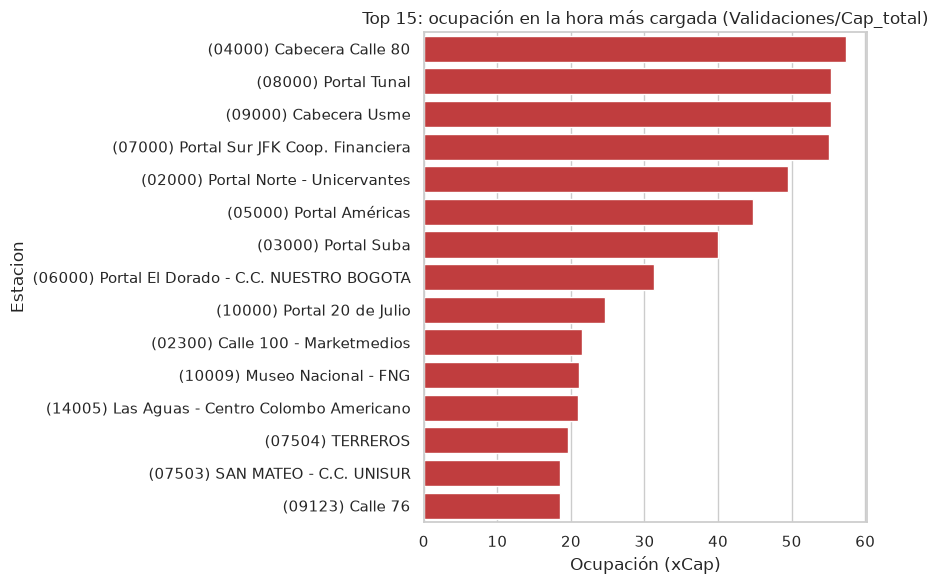

Estaciones que superan el 100 % de capacidad en su peor hora: 133 de 153


In [24]:
ocup = df.dropna(subset=["Cap_total"])
peor = ocup.loc[ocup.groupby("num_est")["Validaciones"].idxmax()]
peor_top = peor.sort_values("Ocupacion_pk", ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=peor_top, x="Ocupacion_pk", y="Estacion", ax=ax, color="#d62728")
ax.set_title('Top 15: ocupación en la hora más cargada (Validaciones/Cap_total)')
ax.set_xlabel('Ocupación (xCap)')
plt.tight_layout(); plt.show()

print("Estaciones que superan el 100 % de capacidad en su peor hora:",
      int((peor["Ocupacion_pk"] > 1).sum()), "de", len(peor))

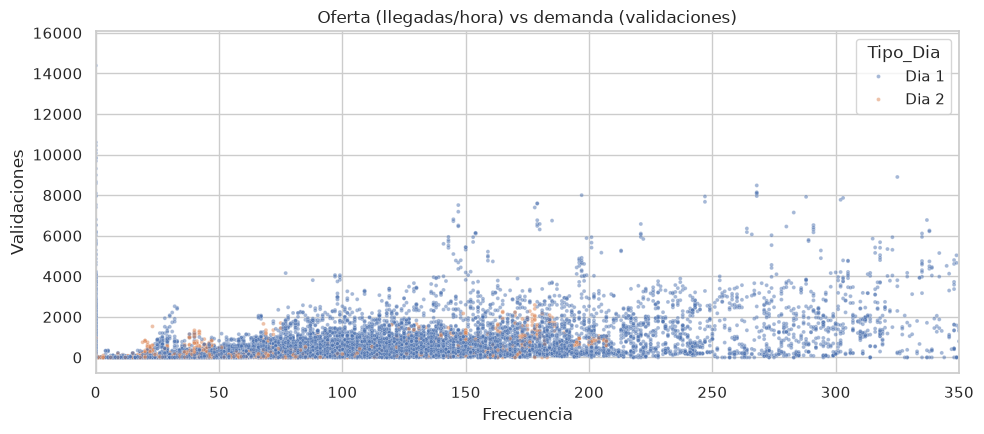

correlación Frecuencia–Validaciones: 0.498


In [25]:
muestra = df.sample(min(25000, len(df)), random_state=0)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax = sns.scatterplot(data=muestra, x="Frecuencia", y="Validaciones",
                     hue="Tipo_Dia", s=8, alpha=.5, ax=ax)
ax.set(title="Oferta (llegadas/hora) vs demanda (validaciones)", xlim=(0, 350))
plt.tight_layout(); plt.show()
print("correlación Frecuencia–Validaciones:", df[["Frecuencia", "Validaciones"]].corr().iloc[0, 1].round(3))

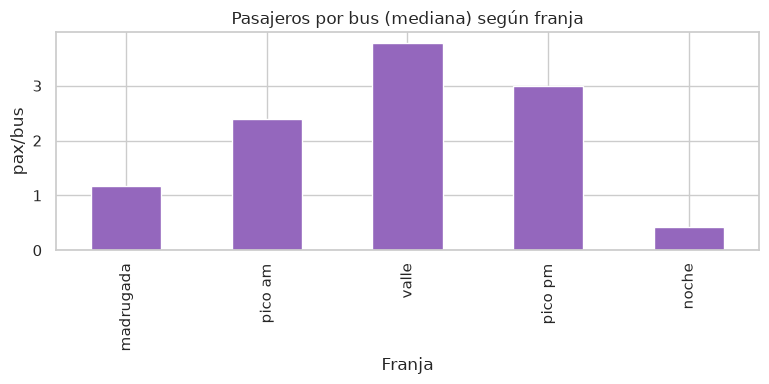

In [26]:
# pasajeros por bus según franja (solo celdas con servicio)
pax_franja = df.dropna(subset=["Pax_bus"]).groupby("Franja")["Pax_bus"].median().reindex(ORDEN_FRANJA)
fig, ax = plt.subplots(figsize=(8, 4))
pax_franja.plot.bar(ax=ax, color="#9467bd")
ax.set_title('Pasajeros por bus (mediana) según franja')
ax.set_ylabel('pax/bus')
plt.tight_layout(); plt.show()

### 5.5 Matriz de correlación numérica

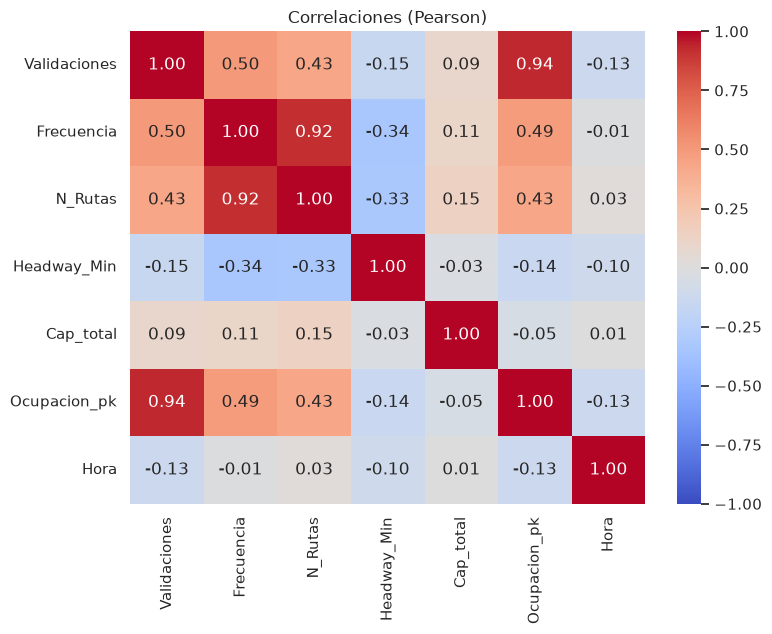

,Validaciones,Frecuencia,N_Rutas,Headway_Min,Cap_total,Ocupacion_pk,Hora
Validaciones,1.00,0.50,0.43,-0.15,0.09,0.94,-0.13
Frecuencia,0.50,1.00,0.92,-0.34,0.11,0.49,-0.01
N_Rutas,0.43,0.92,1.00,-0.33,0.15,0.43,0.03
Headway_Min,-0.15,-0.34,-0.33,1.00,-0.03,-0.14,-0.10
Cap_total,0.09,0.11,0.15,-0.03,1.00,-0.05,0.01
Ocupacion_pk,0.94,0.49,0.43,-0.14,-0.05,1.00,-0.13
Hora,-0.13,-0.01,0.03,-0.10,0.01,-0.13,1.00


In [27]:
cols = ["Validaciones", "Frecuencia", "N_Rutas", "Headway_Min", "Cap_total", "Ocupacion_pk", "Hora"]
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df[cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlaciones (Pearson)")
plt.tight_layout(); plt.show()
corr.round(3)

### 5.6 Conclusiones

Resumimos los hallazgos robustos del EDA:

1. **Volumen:** aprox. 88.9M validaciones en 62 días, 153 estaciones, 12 troncales. El comportamiento de demanda es fuertemente **estacional** (día de la semana + hora), base para el modelo de series temporales por celda.
2. **Doble pico:** la demanda se concentra en `pico am` (05–09 h) y `pico pm` (16–21 h); la forma del día hábil (Dia 1) difiere del domingo (Dia 2): un solo pico vespertino menos acentuado.
3. **Oferta sigue a la demanda** (correlación Frecuencia–Validaciones alta): se refuerza horario pico donde más se usa. El residuo `Validaciones − ⍺·Frecuencia` es una métrica de **sobredemanda** a modelar.
4. **Saturación:** varias estaciones superan el 100 % de su capacidad en la hora pico (ver 5.4). Es el candidato natural a variable objetivo de un análisis de riesgo/congestión.
5. **Cuidados del dataset:** el GTFS no cubre corrales/cables → `Frecuencia` = 0 + flag `Sin_Oferta`; `Cap_total` es NA en esas mismas. Para el modelo, tratar `Frecuencia == 0` no como "cero real" sino como "sin GTFS".

In [28]:
SALIDA_LIMPIO = RUTA_DATASET.parent / "dataset_limpio.csv"
df.to_csv(SALIDA_LIMPIO, index=False)
print("Limpio guardado en:", SALIDA_LIMPIO, "| filas:", len(df), "| columnas:", df.shape[1])

Limpio guardado en: ../../data/transmilenio/dataset_limpio.csv | filas: 176783 | columnas: 28
